In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score, 
    median_absolute_error  
)
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt


# Load GDP data
df = pd.read_csv("Reserach data_GDP.csv")  # Replace with your file path
df['Date'] = pd.date_range(start='2011-04-01', periods=len(df), freq='Q')
df.set_index('Date', inplace=True)
actual = df['GDP(Quaterly)']



In [15]:
df

,Year,GVA at Basic Prices,Primary Sector,Secondary Sector,Tertiary Sector,GDP(Quaterly)
Date,,,,,,
2011-06-30,2011-12_Q1,1969132,403982,589101,976049,2102863
2011-09-30,2011-12_Q2,1913207,326041,570272,1016894,2042870
2011-12-31,2011-12_Q3,2073896,565814,576021,932060,2225135
2012-03-31,2011-12_Q4,2150712,467144,638593,1044975,2365461
2012-06-30,2012-13_Q1,2074589,411979,596685,1065924,2205223
2012-09-30,2012-13_Q2,2047909,329981,607380,1110548,2195946
2012-12-31,2012-13_Q3,2177528,570907,597851,1008770,2344767
2013-03-31,2012-13_Q4,2246251,474030,656642,1115579,2467082
2013-06-30,2013-14_Q1,2206230,422583,631256,1152390,2347396


In [17]:
# 1. Linear Regression
df_lr = df.copy()
df_lr['Time'] = np.arange(len(df_lr))
X = df_lr[['Time']]
y = df_lr['GDP(Quaterly)']
lr_model = LinearRegression()
lr_model.fit(X, y)
future_X = np.arange(len(df_lr) + 4).reshape(-1, 1)
lr_pred = lr_model.predict(future_X)
lr_forecast = pd.DataFrame({'Date': pd.date_range(start=df_lr.index[0], periods=len(future_X), freq='Q'),
                            'Linear_Regression': lr_pred}).set_index('Date')

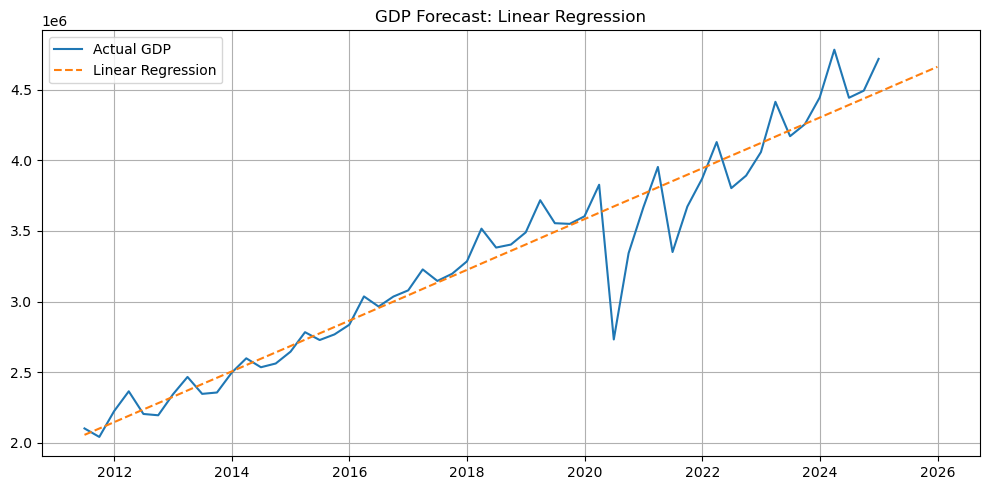

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(actual.index, actual, label='Actual GDP')
plt.plot(lr_forecast.index, lr_forecast['Linear_Regression'], '--', label='Linear Regression')
plt.title('GDP Forecast: Linear Regression')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

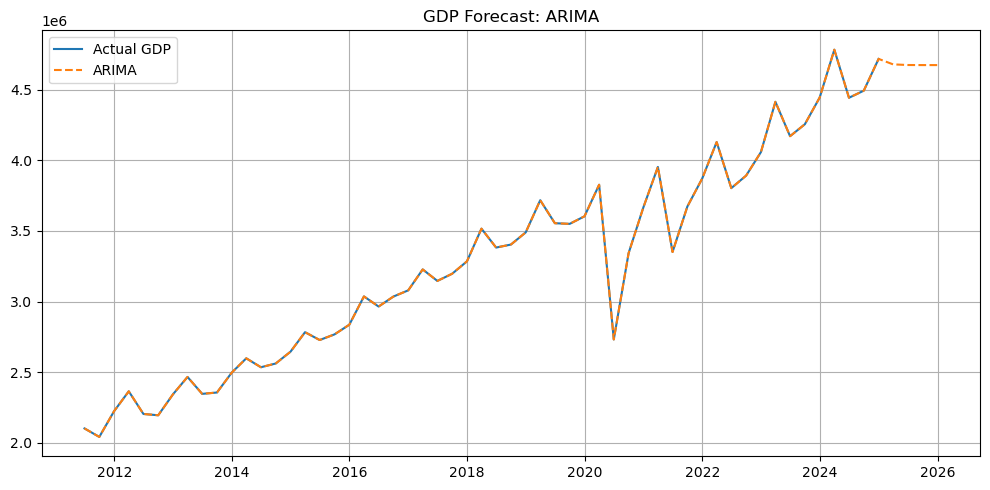

In [21]:
# 2. ARIMA
arima_model = ARIMA(actual, order=(1, 1, 1)).fit()
arima_forecast = arima_model.forecast(steps=4)
arima_full = pd.concat([actual, arima_forecast])
arima_full.index = pd.date_range(start=actual.index[0], periods=len(arima_full), freq='Q')

plt.figure(figsize=(10, 5))
plt.plot(actual.index, actual, label='Actual GDP')
plt.plot(arima_full.index, arima_full.values, '--', label='ARIMA')
plt.title('GDP Forecast: ARIMA')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

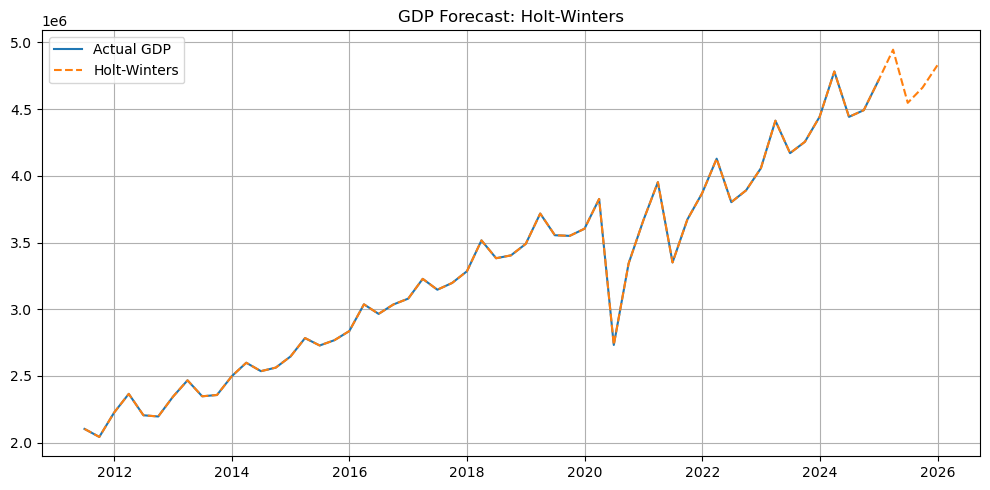

In [22]:
# 3. Holt-Winters
hw_model = ExponentialSmoothing(actual, trend='add', seasonal='add', seasonal_periods=4).fit()
hw_forecast = hw_model.forecast(steps=4)
hw_full = pd.concat([actual, hw_forecast])
hw_full.index = pd.date_range(start=actual.index[0], periods=len(hw_full), freq='Q')

plt.figure(figsize=(10, 5))
plt.plot(actual.index, actual, label='Actual GDP')
plt.plot(hw_full.index, hw_full.values, '--', label='Holt-Winters')
plt.title('GDP Forecast: Holt-Winters')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

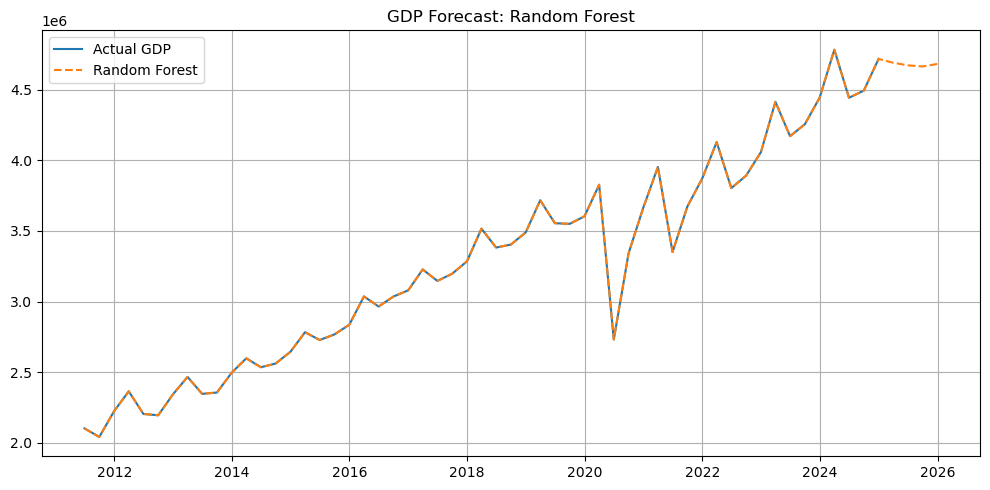

In [23]:
# 4. Random Forest
df_rf = df[['GDP(Quaterly)']].copy()
for i in range(1, 5):
    df_rf[f'lag_{i}'] = df_rf['GDP(Quaterly)'].shift(i)
df_rf.dropna(inplace=True)
X_rf = df_rf[[f'lag_{i}' for i in range(1, 5)]]
y_rf = df_rf['GDP(Quaterly)']
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_model.fit(X_rf, y_rf)
last_known = df_rf.iloc[-1][[f'lag_{i}' for i in range(1, 5)]].values.tolist()
rf_forecast = []
for _ in range(4):
    next_val = rf_model.predict([last_known])[0]
    rf_forecast.append(next_val)
    last_known = [next_val] + last_known[:-1]
rf_full = pd.concat([
    actual,
    pd.Series(rf_forecast, index=pd.date_range(start=actual.index[-1] + pd.DateOffset(months=3), periods=4, freq='Q'))
])

plt.figure(figsize=(10, 5))
plt.plot(actual.index, actual, label='Actual GDP')
plt.plot(rf_full.index, rf_full.values, '--', label='Random Forest')
plt.title('GDP Forecast: Random Forest')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

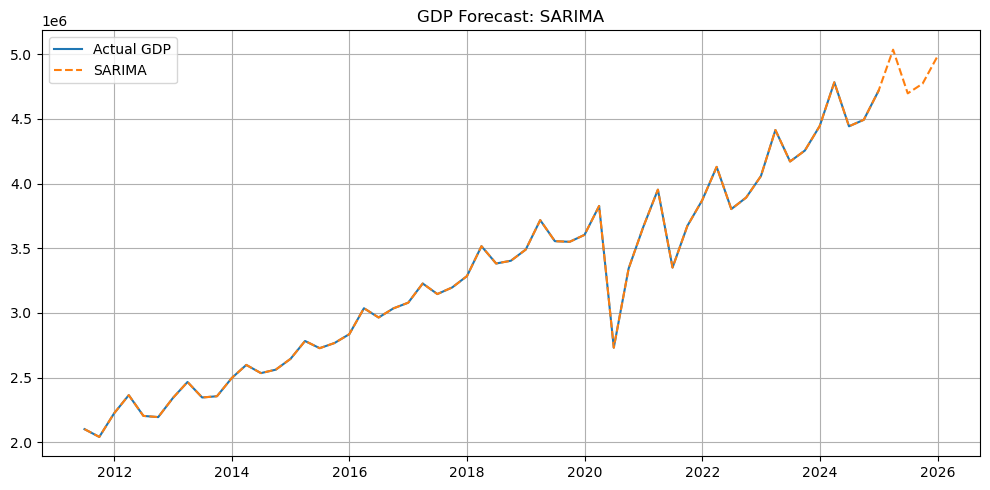

In [25]:
# 5. SARIMA
sarima_model = SARIMAX(actual, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4)).fit()
sarima_forecast = sarima_model.forecast(steps=4)
sarima_full = pd.concat([actual, sarima_forecast])
sarima_full.index = pd.date_range(start=actual.index[0], periods=len(sarima_full), freq='Q')

plt.figure(figsize=(10, 5))
plt.plot(actual.index, actual, label='Actual GDP')
plt.plot(sarima_full.index, sarima_full.values, '--', label='SARIMA')
plt.title('GDP Forecast: SARIMA')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

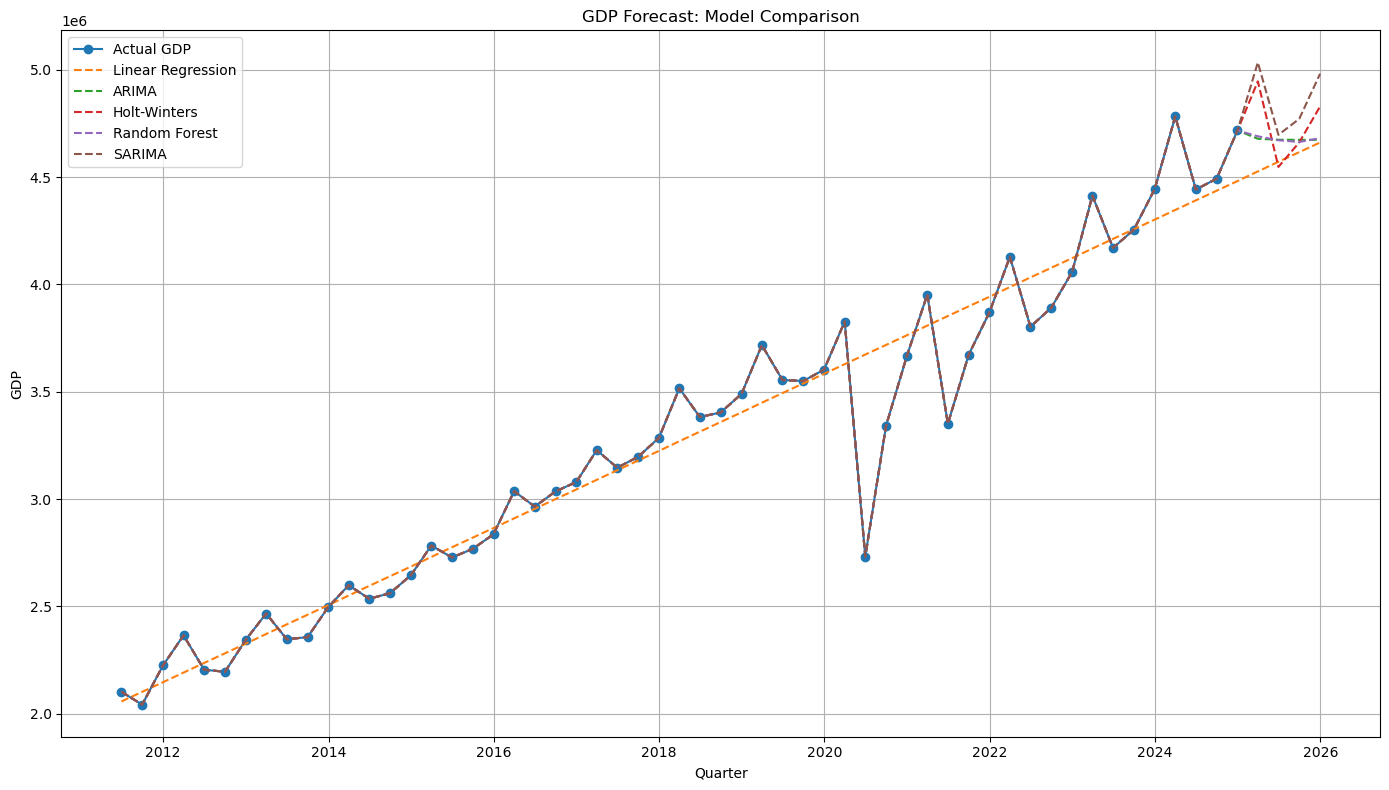

In [26]:
# Final Combined Plot
plt.figure(figsize=(14, 8))
plt.plot(actual.index, actual, label='Actual GDP', marker='o')
plt.plot(lr_forecast.index, lr_forecast['Linear_Regression'], '--', label='Linear Regression')
plt.plot(arima_full.index, arima_full.values, '--', label='ARIMA')
plt.plot(hw_full.index, hw_full.values, '--', label='Holt-Winters')
plt.plot(rf_full.index, rf_full.values, '--', label='Random Forest')
plt.plot(sarima_full.index, sarima_full.values, '--', label='SARIMA')
plt.title('GDP Forecast: Model Comparison')
plt.xlabel('Quarter')
plt.ylabel('GDP')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# Add this custom MAPE function
def mean_absolute_percentage_error(y_true, y_pred):
    """Custom MAPE function"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [29]:
train = df.iloc[:-4]
test = df.iloc[-4:]
y_train = train['GDP(Quaterly)']
y_test = test['GDP(Quaterly)']

# 1. Linear Regression
train_lr = train.copy()
train_lr['Time'] = np.arange(len(train_lr))
X_train_lr = train_lr[['Time']]
lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train)
X_test_lr = np.arange(len(train_lr), len(train_lr) + 4).reshape(-1, 1)
lr_test_pred = lr_model.predict(X_test_lr)

In [30]:
# 2. ARIMA
arima_model = ARIMA(y_train, order=(1, 1, 1)).fit()
arima_test_pred = arima_model.forecast(steps=4)



In [32]:
# 3. Holt-Winters
hw_model = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=4).fit()
hw_test_pred = hw_model.forecast(steps=4)

In [33]:
# 4. Random Forest
train_rf = train[['GDP(Quaterly)']].copy()
for i in range(1, 5):
    train_rf[f'lag_{i}'] = train_rf['GDP(Quaterly)'].shift(i)
train_rf.dropna(inplace=True)
X_train_rf = train_rf[[f'lag_{i}' for i in range(1, 5)]]
y_train_rf = train_rf['GDP(Quaterly)']
rf_model = RandomForestRegressor(n_estimators=100, random_state=0)
rf_model.fit(X_train_rf, y_train_rf)

RandomForestRegressor(random_state=0)

In [34]:
# Use last lags for recursive prediction
last_known = train_rf.iloc[-1][[f'lag_{i}' for i in range(1, 5)]].tolist()
rf_test_pred = []
for _ in range(4):
    next_val = rf_model.predict([last_known])[0]
    rf_test_pred.append(next_val)
    last_known = [next_val] + last_known[:-1]

In [36]:
# 5. SARIMA
sarima_model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4)).fit()
sarima_test_pred = sarima_model.forecast(steps=4)

In [37]:
# Evaluation metrics
performance_metrics = pd.DataFrame({
    'Model': ['Linear Regression', 'ARIMA', 'Holt-Winters', 'Random Forest', 'SARIMA'],
    'RMSE': [
        mean_squared_error(y_test, lr_test_pred, squared=False),
        mean_squared_error(y_test, arima_test_pred, squared=False),
        mean_squared_error(y_test, hw_test_pred, squared=False),
        mean_squared_error(y_test, rf_test_pred, squared=False),
        mean_squared_error(y_test, sarima_test_pred, squared=False)
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_test_pred),
        mean_absolute_error(y_test, arima_test_pred),
        mean_absolute_error(y_test, hw_test_pred),
        mean_absolute_error(y_test, rf_test_pred),
        mean_absolute_error(y_test, sarima_test_pred)
    ],
    'MAPE (%)': [
        mean_absolute_percentage_error(y_test, lr_test_pred) * 100,
        mean_absolute_percentage_error(y_test, arima_test_pred) * 100,
        mean_absolute_percentage_error(y_test, hw_test_pred) * 100,
        mean_absolute_percentage_error(y_test, rf_test_pred) * 100,
        mean_absolute_percentage_error(y_test, sarima_test_pred) * 100
    ],
    'Median AE': [
        median_absolute_error(y_test, lr_test_pred),
        median_absolute_error(y_test, arima_test_pred),
        median_absolute_error(y_test, hw_test_pred),
        median_absolute_error(y_test, rf_test_pred),
        median_absolute_error(y_test, sarima_test_pred)
    ],
    'R2 Score': [
        r2_score(y_test, lr_test_pred),
        r2_score(y_test, arima_test_pred),
        r2_score(y_test, hw_test_pred),
        r2_score(y_test, rf_test_pred),
        r2_score(y_test, sarima_test_pred)
    ]
})

# Print or return results
print(performance_metrics)

               Model           RMSE            MAE    MAPE (%)      Median AE  \
0  Linear Regression  305573.160211  262158.825264  559.322223  215482.776486   
1              ARIMA  247287.372884  201654.060829  428.297567  198996.762178   
2       Holt-Winters  158487.759170  153604.389975  333.447084  162962.430117   
3      Random Forest  272157.535815  233015.025000  496.589709  233959.900000   
4             SARIMA   70654.310055   62691.325418  137.552858   60945.204433   

   R2 Score  
0 -3.492996  
1 -1.942453  
2 -0.208640  
3 -2.564071  
4  0.759795  


In [39]:
df.describe()

,GVA at Basic Prices,Primary Sector,Secondary Sector,Tertiary Sector,GDP(Quaterly)
count,5.500000e+01,55.000000,5.500000e+01,5.500000e+01,5.500000e+01
mean,3.008136e+06,549297.800000,8.558903e+05,1.602948e+06,3.269303e+06
std,6.703657e+05,126680.809146,1.958350e+05,3.991372e+05,7.461414e+05
min,1.913207e+06,326041.000000,5.702720e+05,9.320600e+05,2.042870e+06
25%,2.418183e+06,458632.000000,6.779795e+05,1.265152e+06,2.622422e+06
50%,3.032795e+06,535772.000000,8.494300e+05,1.624159e+06,3.284992e+06
75%,3.469735e+06,631212.500000,9.835935e+05,1.883699e+06,3.814724e+06
max,4.312585e+06,850955.000000,1.305076e+06,2.427016e+06,4.782032e+06


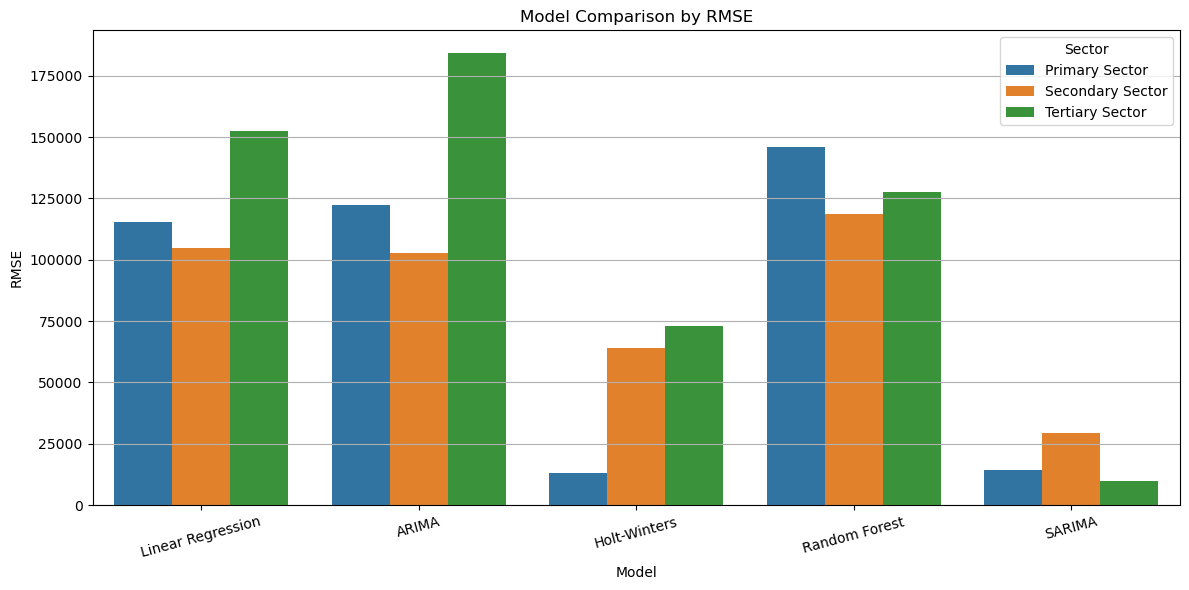

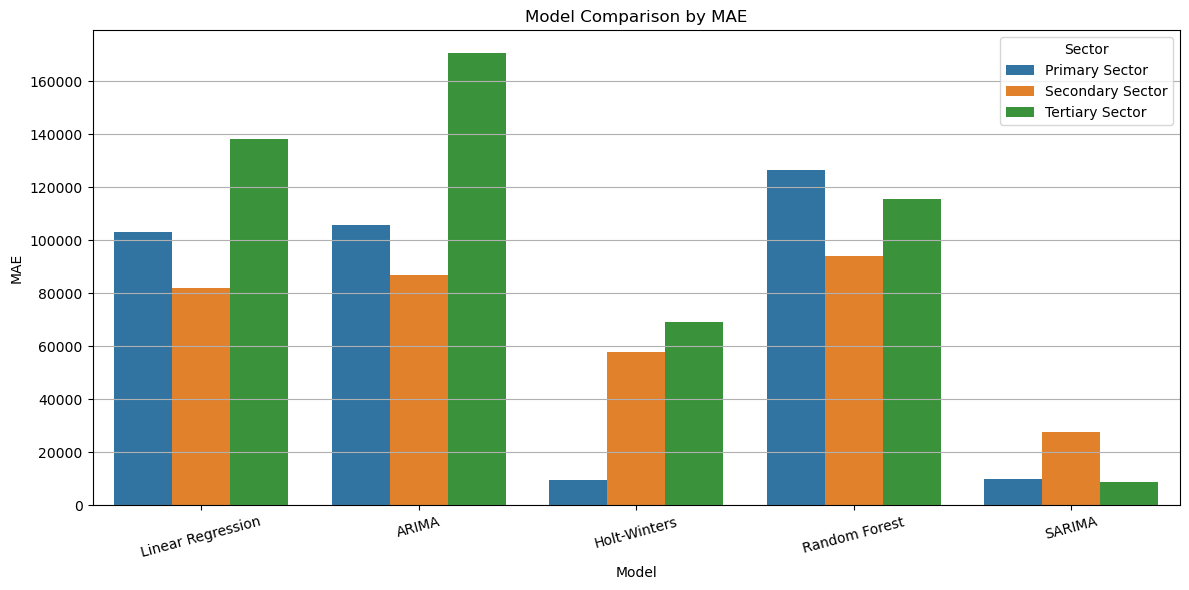

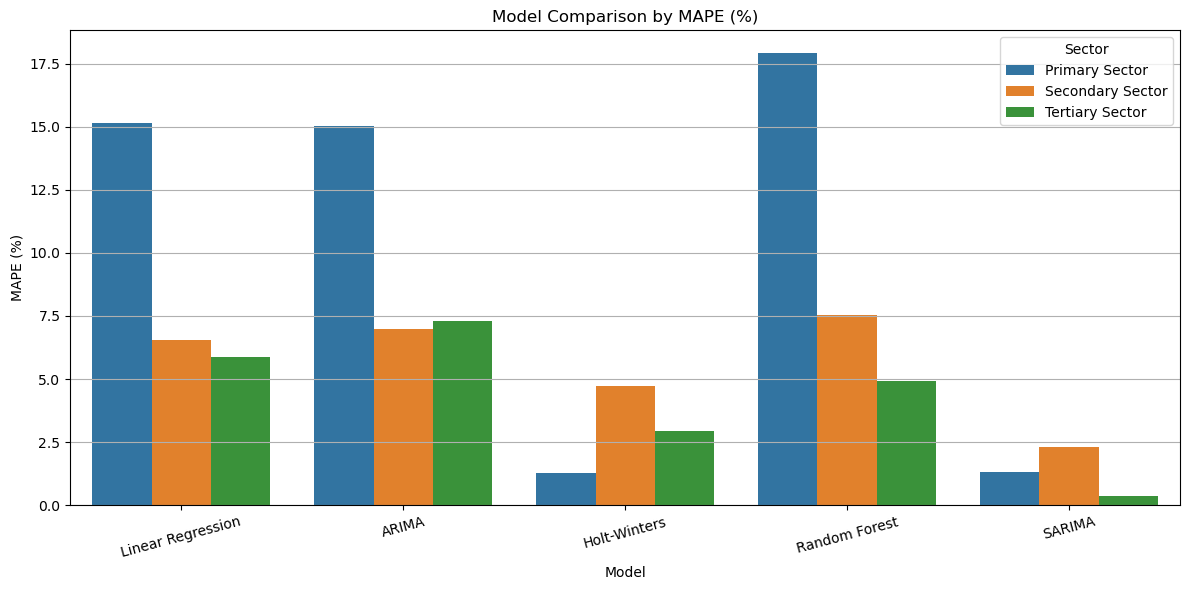

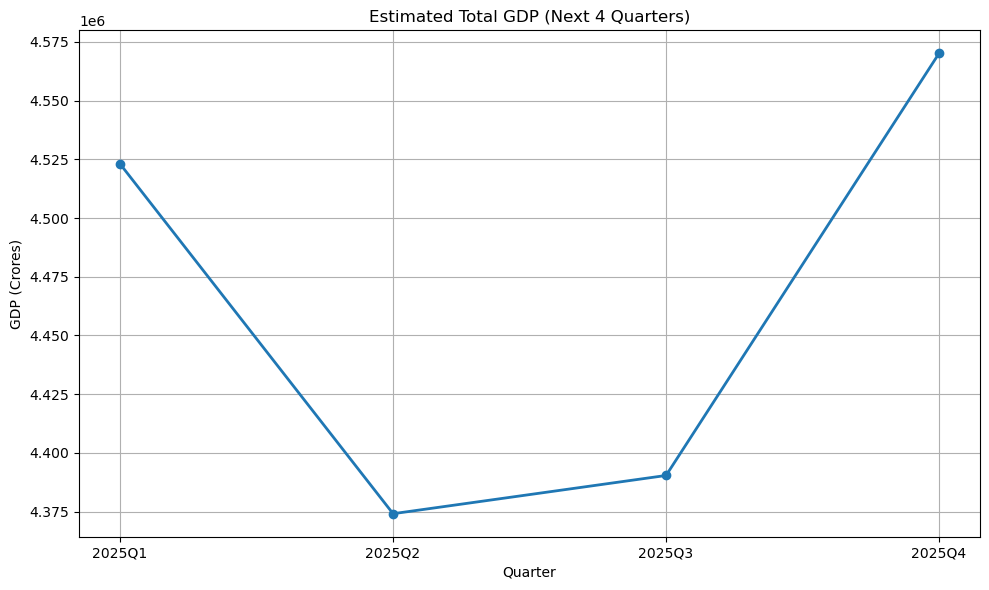


Estimated Total GDP Forecast (Next 4 Quarters):
Quarter  Primary Sector  Secondary Sector  Tertiary Sector  Estimated GDP
 2025Q1   789855.124035      1.344641e+06     2.388533e+06   4.523029e+06
 2025Q2   683196.437841      1.222466e+06     2.468412e+06   4.374075e+06
 2025Q3   587515.031433      1.232663e+06     2.570182e+06   4.390360e+06
 2025Q4   895163.714194      1.239845e+06     2.435134e+06   4.570142e+06


In [43]:
def evaluate_sector_performance(df, column_name):
    train = df.iloc[:-4]
    test = df.iloc[-4:]
    y_train = train[column_name]
    y_test = test[column_name]

    # Baseline Linear Regression
    train['Time'] = np.arange(len(train))
    X_train = train[['Time']]
    from sklearn.linear_model import LinearRegression
    lr = LinearRegression().fit(X_train, y_train)
    X_test = np.arange(len(train), len(train) + 4).reshape(-1, 1)
    lr_pred = lr.predict(X_test)

    # ARIMA
    from statsmodels.tsa.arima.model import ARIMA
    arima = ARIMA(y_train, order=(1, 1, 1)).fit()
    arima_pred = arima.forecast(steps=4)

    # Holt-Winters
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    hw = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=4).fit()
    hw_pred = hw.forecast(steps=4)

    # Random Forest
    from sklearn.ensemble import RandomForestRegressor
    train_rf = train[[column_name]].copy()
    for i in range(1, 5):
        train_rf[f'lag_{i}'] = train_rf[column_name].shift(i)
    train_rf.dropna(inplace=True)
    X_rf = train_rf[[f'lag_{i}' for i in range(1, 5)]]
    y_rf = train_rf[column_name]
    rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(X_rf, y_rf)
    last_known = train_rf.iloc[-1][[f'lag_{i}' for i in range(1, 5)]].tolist()
    rf_pred = []
    for _ in range(4):
        next_val = rf.predict([last_known])[0]
        rf_pred.append(next_val)
        last_known = [next_val] + last_known[:-1]

    # SARIMA
    sarima = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4)).fit(disp=False)
    sarima_pred = sarima.forecast(steps=4)

    # Evaluation
    models = ['Linear Regression', 'ARIMA', 'Holt-Winters', 'Random Forest', 'SARIMA']
    results = pd.DataFrame({
        'Model': models,
        'RMSE': [
            mean_squared_error(y_test, lr_pred, squared=False),
            mean_squared_error(y_test, arima_pred, squared=False),
            mean_squared_error(y_test, hw_pred, squared=False),
            mean_squared_error(y_test, rf_pred, squared=False),
            mean_squared_error(y_test, sarima_pred, squared=False)
        ],
        'MAE': [
            mean_absolute_error(y_test, lr_pred),
            mean_absolute_error(y_test, arima_pred),
            mean_absolute_error(y_test, hw_pred),
            mean_absolute_error(y_test, rf_pred),
            mean_absolute_error(y_test, sarima_pred)
        ],
        'MAPE (%)': [
            mean_absolute_percentage_error(y_test, lr_pred),
            mean_absolute_percentage_error(y_test, arima_pred),
            mean_absolute_percentage_error(y_test, hw_pred),
            mean_absolute_percentage_error(y_test, rf_pred),
            mean_absolute_percentage_error(y_test, sarima_pred)
        ],
        'R2 Score': [
            r2_score(y_test, lr_pred),
            r2_score(y_test, arima_pred),
            r2_score(y_test, hw_pred),
            r2_score(y_test, rf_pred),
            r2_score(y_test, sarima_pred)
        ],
        'Median AE': [
            median_absolute_error(y_test, lr_pred),
            median_absolute_error(y_test, arima_pred),
            median_absolute_error(y_test, hw_pred),
            median_absolute_error(y_test, rf_pred),
            median_absolute_error(y_test, sarima_pred)
        ]
    })

    results['Sector'] = column_name
    return results

# Run for all three sectors
primary = evaluate_sector_performance(df, 'Primary Sector')
secondary = evaluate_sector_performance(df, 'Secondary Sector')
tertiary = evaluate_sector_performance(df, 'Tertiary Sector')

# Combine for plotting
combined_perf = pd.concat([primary, secondary, tertiary], ignore_index=True)

# Plot RMSE, MAE, MAPE
metrics = ['RMSE', 'MAE', 'MAPE (%)']
for metric in metrics:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=combined_perf, x='Model', y=metric, hue='Sector')
    plt.title(f'Model Comparison by {metric}')
    plt.xticks(rotation=15)
    plt.ylabel(metric)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# ---------------- Forecast Total GDP Using Sector-wise SARIMA ----------------

def forecast_sarima(series):
    model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4)).fit(disp=False)
    return model.forecast(steps=4)

primary_forecast = forecast_sarima(df['Primary Sector'])
secondary_forecast = forecast_sarima(df['Secondary Sector'])
tertiary_forecast = forecast_sarima(df['Tertiary Sector'])

total_gdp_forecast = primary_forecast + secondary_forecast + tertiary_forecast
forecast_index = pd.date_range(start=df.index[-1] + pd.DateOffset(months=3), periods=4, freq='Q')

# Final DataFrame
gdp_df = pd.DataFrame({
    'Quarter': forecast_index.to_period('Q').astype(str),
    'Primary Sector': primary_forecast.values,
    'Secondary Sector': secondary_forecast.values,
    'Tertiary Sector': tertiary_forecast.values,
    'Estimated GDP': total_gdp_forecast.values
})

# Plot GDP forecast
plt.figure(figsize=(10, 6))
plt.plot(gdp_df['Quarter'], gdp_df['Estimated GDP'], marker='o', label='Estimated Total GDP', linewidth=2)
plt.title("Estimated Total GDP (Next 4 Quarters)")
plt.xlabel("Quarter")
plt.ylabel("GDP (Crores)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Print table
print("\nEstimated Total GDP Forecast (Next 4 Quarters):")
print(gdp_df.to_string(index=False))